### Step 1: Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [93]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn import metrics
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

In [92]:
from xgboost import XGBClassifier
from imblearn.over_sampling import RandomOverSampler
from feature_engine.selection import SmartCorrelatedSelection

### Step 2: Load Data

In [5]:
df = pd.read_csv('./data/Rainfall.csv')

In [19]:
df.rename(str.strip, axis='columns', inplace=True)

In [6]:
df.shape

(366, 12)

In [7]:
df.head()

,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1,1025.9,19.9,18.3,16.8,13.1,72,49,yes,9.3,80.0,26.3
1,2,1022.0,21.7,18.9,17.2,15.6,81,83,yes,0.6,50.0,15.3
2,3,1019.7,20.3,19.3,18.0,18.4,95,91,yes,0.0,40.0,14.2
3,4,1018.9,22.3,20.6,19.1,18.8,90,88,yes,1.0,50.0,16.9
4,5,1015.9,21.3,20.7,20.2,19.9,95,81,yes,0.0,40.0,13.7


### Step 3: Exploaring Data

#### Basic Info

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
day,366.0,15.756831,8.823592,1.0,8.000,16.00,23.000,31.0
pressure,366.0,1013.742623,6.414776,998.5,1008.500,1013.00,1018.100,1034.6
maxtemp,366.0,26.191257,5.978343,7.1,21.200,27.75,31.200,36.3
temparature,366.0,23.747268,5.632813,4.9,18.825,25.45,28.600,32.4
mintemp,366.0,21.894536,5.594153,3.1,17.125,23.70,26.575,30.0
dewpoint,366.0,19.989071,5.997021,-0.4,16.125,21.95,25.000,26.7
humidity,366.0,80.177596,10.062470,36.0,75.000,80.50,87.000,98.0
cloud,366.0,71.128415,21.798012,0.0,58.000,80.00,88.000,100.0
sunshine,366.0,4.419399,3.934398,0.0,0.500,3.50,8.200,12.1
winddirection,365.0,101.506849,81.723724,10.0,40.000,70.00,190.000,350.0


In [11]:
feature_info = pd.DataFrame(
    {
        'null': df.isnull().sum(),
        'null(%)':round(100 * df.isnull().sum() / len(df), 3),
        'unique': df.nunique(),
        'type': df.dtypes
    }
)

In [12]:
feature_info

,null,null(%),unique,type
day,0,0.000,31,int64
pressure,0,0.000,188,float64
maxtemp,0,0.000,174,float64
temparature,0,0.000,158,float64
mintemp,0,0.000,157,float64
dewpoint,0,0.000,158,float64
humidity,0,0.000,49,int64
cloud,0,0.000,79,int64
rainfall,0,0.000,2,object
sunshine,0,0.000,104,float64


#### Target Distribution

In [13]:
temp = df['rainfall'].value_counts()

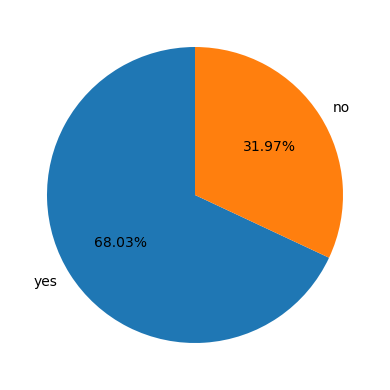

In [16]:
plt.figure(figsize=(4, 4))
plt.pie(
    temp,
    autopct='%.2f%%',
    labels=temp.index,
    startangle=90
)
plt.tight_layout()

In [31]:
num_cols

['day',
 'pressure',
 'maxtemp',
 'temparature',
 'mintemp',
 'dewpoint',
 'humidity',
 'cloud',
 'sunshine',
 'winddirection',
 'windspeed']

#### Number Distribution

In [25]:
num_cols = df.select_dtypes(np.number).columns.to_list()

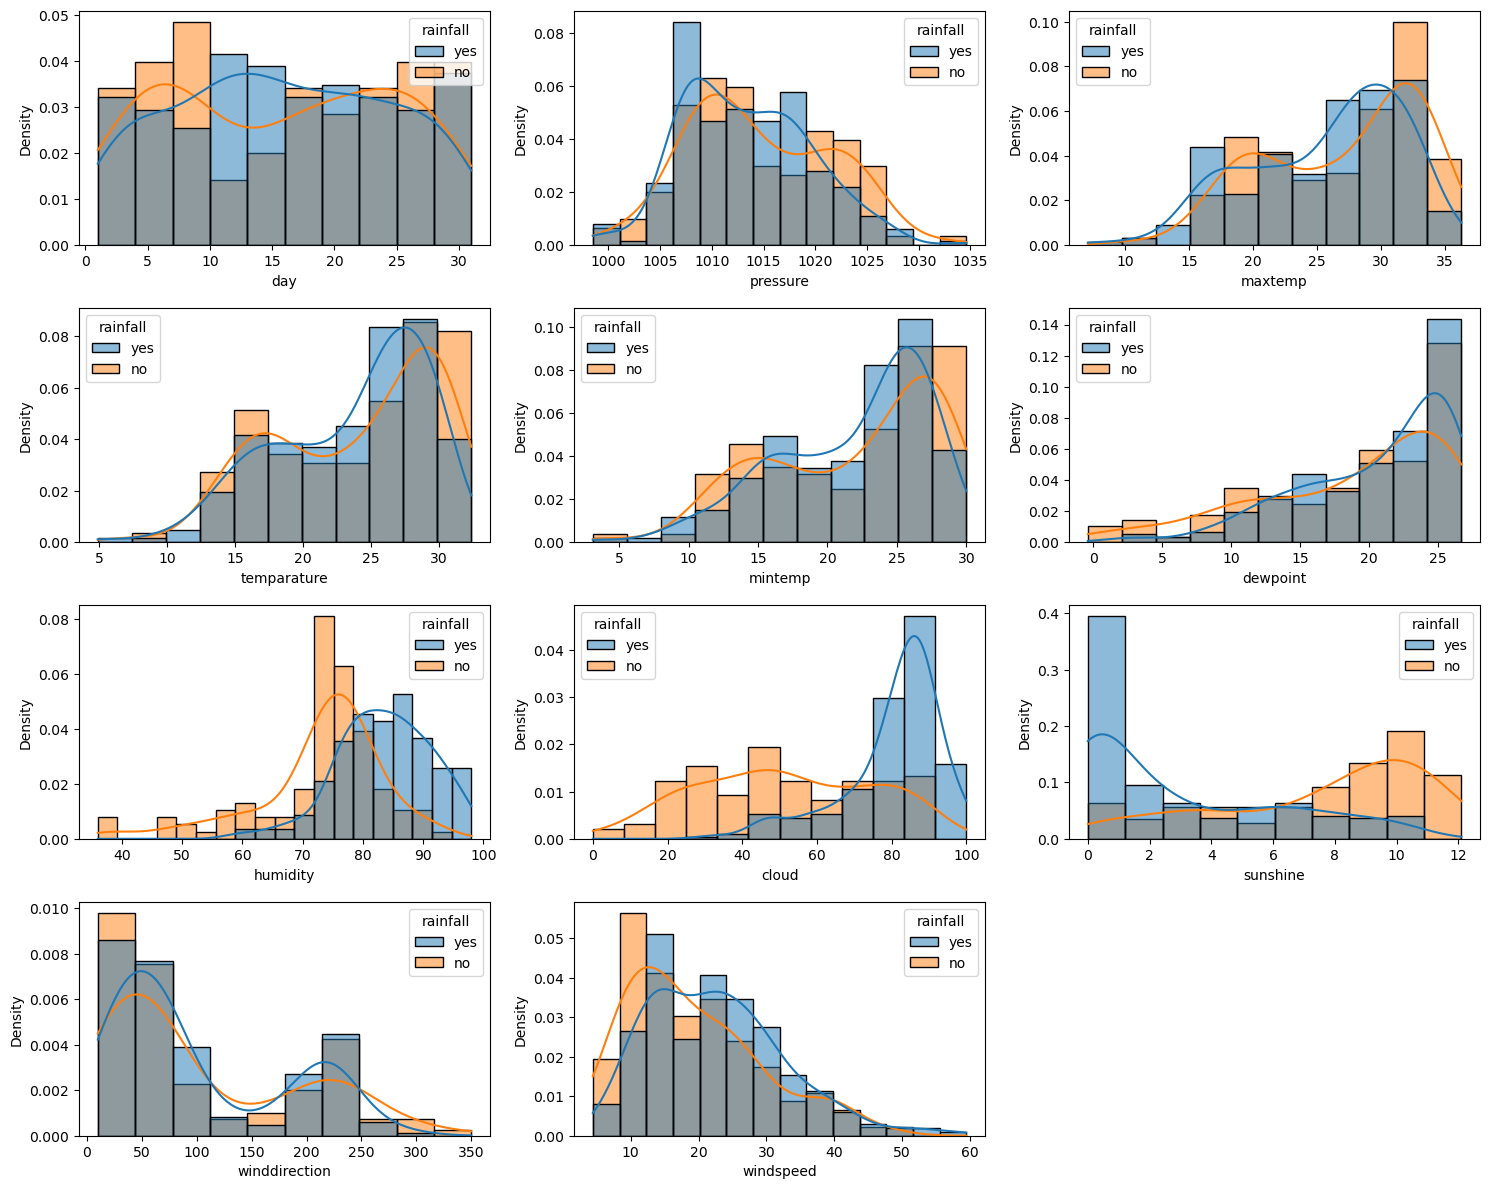

In [56]:
plt.figure(figsize=(15, 12))
for i, col in enumerate(num_cols):
    plt.subplot(4, 3, i+1)
    sns.histplot(x=col, hue='rainfall', data=df, kde=True, stat='density', common_norm=False)
plt.tight_layout()

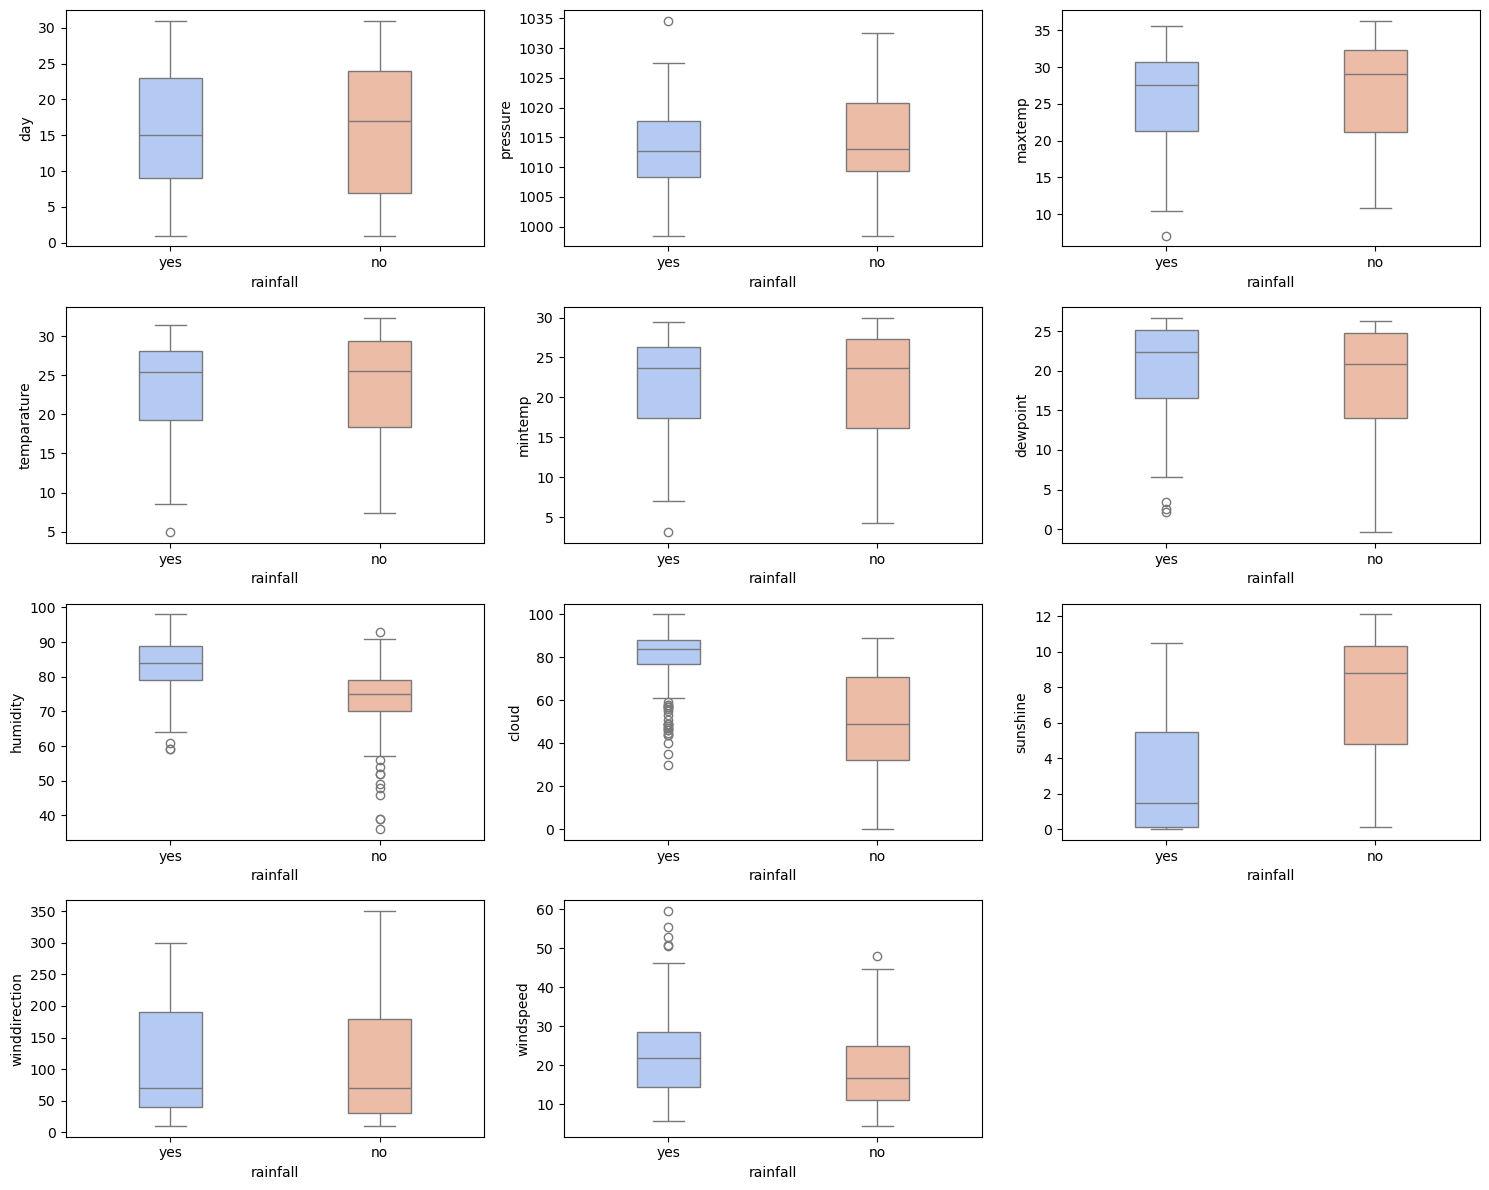

In [68]:
plt.figure(figsize=(15, 12))
for i, col in enumerate(num_cols):
    plt.subplot(4, 3, i+1)
    sns.boxplot(y=col, x='rainfall', data=df, width=0.3, palette='coolwarm')
plt.tight_layout()

### Step 4: Feature Encod

#### Handling Missing Value

In [21]:
miss_cols = ['winddirection', 'windspeed']

In [22]:
for col in miss_cols:
    df[col] = df[col].fillna(df[col].mean())

#### Label Encoding

In [70]:
le = LabelEncoder()

In [71]:
df['rainfall'] = le.fit_transform(df['rainfall'])

#### Heat Map

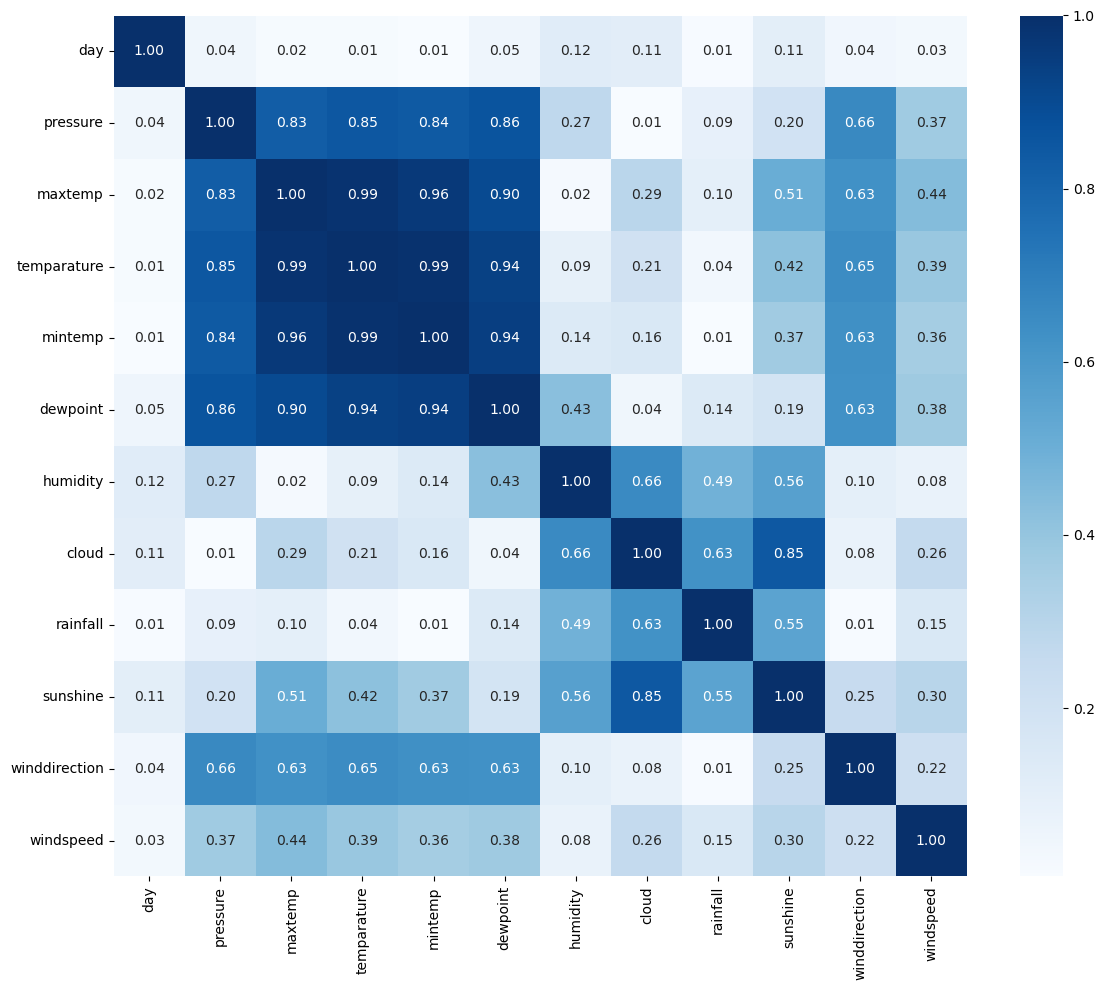

In [73]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    df.corr().abs(),
    annot=True,
    fmt='.2f',
    cmap=plt.cm.Blues
)
plt.tight_layout()

### Step 5: Preparing Data

#### Select Features

In [134]:
features = df.drop(['rainfall', 'day'], axis=1)
target = df['rainfall']

In [135]:
raw_features = features.columns.to_list()

In [136]:
selector = SmartCorrelatedSelection(threshold=0.7, selection_method='corr_with_target')

In [137]:
features = selector.fit_transform(features, target)

In [138]:
deal_features = features.columns.to_list()

In [139]:
print('raw features:', raw_features)
print('deal features:', deal_features)
print('delete features:', set(raw_features)-set(deal_features))

raw features: ['pressure', 'maxtemp', 'temparature', 'mintemp', 'dewpoint', 'humidity', 'cloud', 'sunshine', 'winddirection', 'windspeed']
deal features: ['dewpoint', 'humidity', 'cloud', 'winddirection', 'windspeed']
delete features: {'maxtemp', 'temparature', 'sunshine', 'pressure', 'mintemp'}


#### Split Data

In [140]:
X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42
)

#### Balance Data

In [141]:
ros = RandomOverSampler(sampling_strategy='minority', random_state=42)

In [142]:
X_train, y_train = ros.fit_resample(X_train, y_train)

#### Normalization

In [143]:
scaler = StandardScaler()

In [144]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Step 6: Model Development

In [145]:
models = [
    LogisticRegression(),
    XGBClassifier(),
    SVC(probability=True)
]

In [146]:
for model in models:
    print(model.__class__.__name__)
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring='roc_auc',
        n_jobs=-1,
        error_score='raise'
    )
    print('Training Accuracy Scores:', [round(x, 3) for x in scores])
    print('Training Accuracy Score:', round(scores.mean(), 3))

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print('Testing Accuracy score:', round(metrics.roc_auc_score(y_test, y_pred), 3))
    print('-' * 20)

LogisticRegression
Training Accuracy Scores: [0.851, 0.919, 0.908, 0.921, 0.881]
Training Accuracy Score: 0.896
Testing Accuracy score: 0.724
--------------------
XGBClassifier
Training Accuracy Scores: [0.916, 0.948, 0.919, 0.971, 0.949]
Training Accuracy Score: 0.94
Testing Accuracy score: 0.651
--------------------
SVC
Training Accuracy Scores: [0.819, 0.918, 0.872, 0.925, 0.89]
Training Accuracy Score: 0.885
Testing Accuracy score: 0.724
--------------------


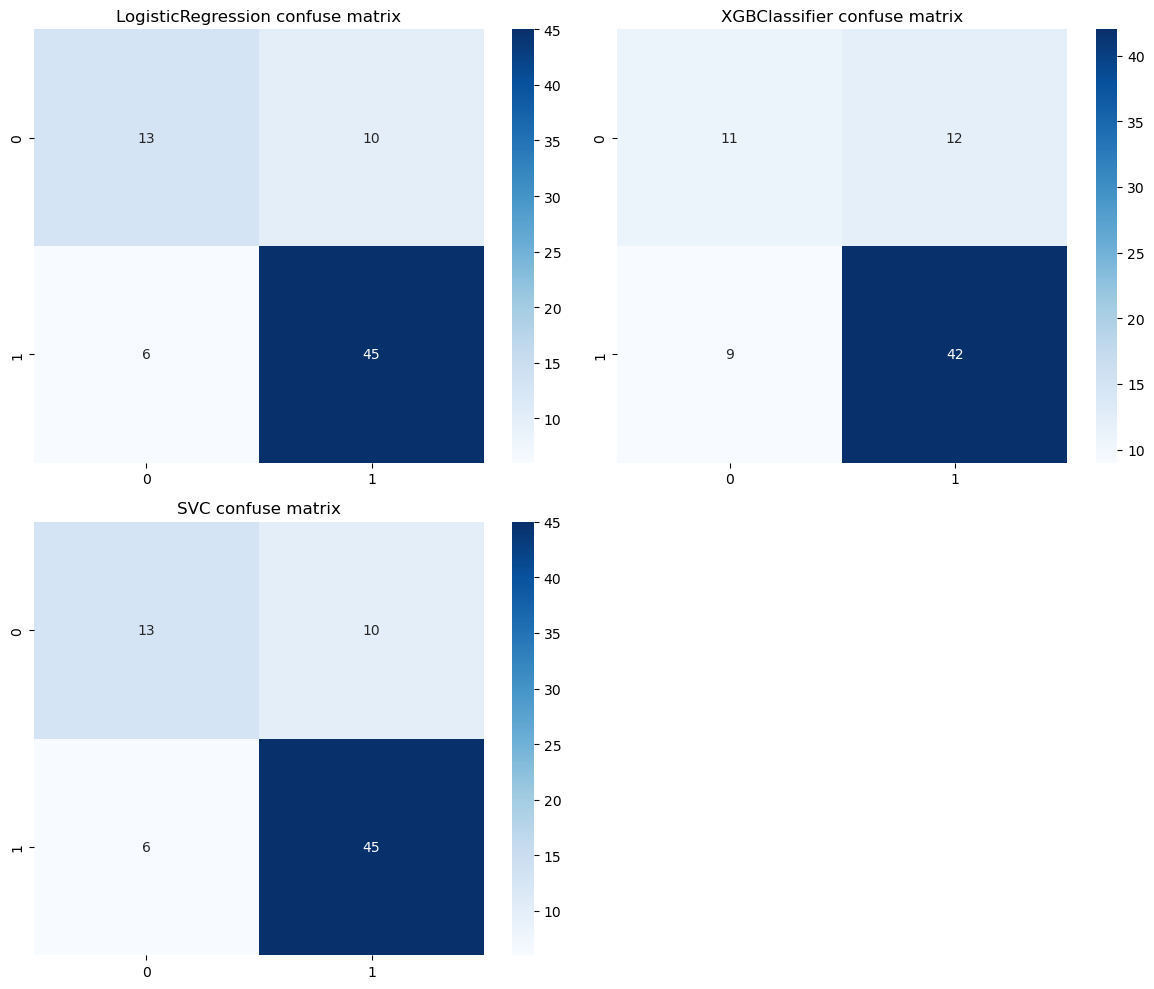

In [149]:
plt.figure(figsize=(12, 10))
for i, model in enumerate(models):
    plt.subplot(2, 2, i+1)
    cm = metrics.confusion_matrix(y_test, model.predict(X_test))
    sns.heatmap(
        cm,
        fmt='d',
        annot=True,
        cmap=plt.cm.Blues
    )
    plt.title(f'{model.__class__.__name__} confuse matrix')
plt.tight_layout()

In [151]:
print(
    metrics.classification_report(
        y_test,
        models[0].predict(X_test)
    )
)

              precision    recall  f1-score   support

           0       0.68      0.57      0.62        23
           1       0.82      0.88      0.85        51

    accuracy                           0.78        74
   macro avg       0.75      0.72      0.73        74
weighted avg       0.78      0.78      0.78        74



In [152]:
print(
    metrics.classification_report(
        y_test,
        models[1].predict(X_test)
    )
)

              precision    recall  f1-score   support

           0       0.55      0.48      0.51        23
           1       0.78      0.82      0.80        51

    accuracy                           0.72        74
   macro avg       0.66      0.65      0.66        74
weighted avg       0.71      0.72      0.71        74



In [153]:
print(
    metrics.classification_report(
        y_test,
        models[2].predict(X_test)
    )
)

              precision    recall  f1-score   support

           0       0.68      0.57      0.62        23
           1       0.82      0.88      0.85        51

    accuracy                           0.78        74
   macro avg       0.75      0.72      0.73        74
weighted avg       0.78      0.78      0.78        74

